In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from churn_prediction.paths import PROCESSED_DIR

In [2]:
print("\n1. ĐỌC DỮ LIỆU")

customer_df = pd.read_parquet(PROCESSED_DIR / 'customer_level.parquet')
print(f"   Customer_df shape: {customer_df.shape}")
print(f"   Số khách hàng thực: {len(customer_df):,}")


1. ĐỌC DỮ LIỆU
   Customer_df shape: (96096, 32)
   Số khách hàng thực: 96,096



2. PHÂN PHỐI days_since_last_purchase
count    96096.000000
mean       287.735691
std        153.414676
min          0.000000
25%        163.000000
50%        268.000000
75%        397.000000
max        772.000000
Name: days_since_last_purchase, dtype: float64


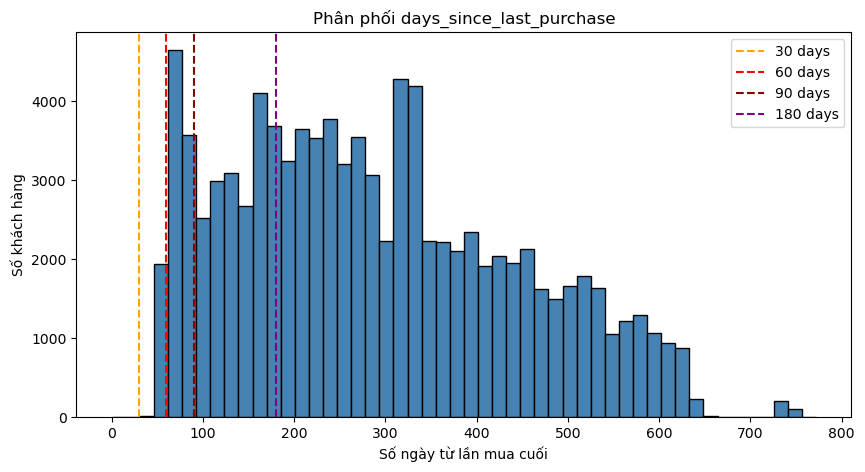

In [7]:
print("\n2. PHÂN PHỐI days_since_last_purchase")

print(customer_df['days_since_last_purchase'].describe())

# Vẽ histogram để chọn ngưỡng
plt.figure(figsize=(10, 5))
plt.hist(customer_df['days_since_last_purchase'], bins=50, color='steelblue', edgecolor='black')
plt.axvline(x=30, color='orange', linestyle='--', label='30 days')
plt.axvline(x=60, color='red', linestyle='--', label='60 days')
plt.axvline(x=90, color='darkred', linestyle='--', label='90 days')
plt.axvline(x=180, color='purple', linestyle='--', label='180 days')
plt.title('Phân phối days_since_last_purchase')
plt.xlabel('Số ngày từ lần mua cuối')
plt.ylabel('Số khách hàng')
plt.legend()
plt.show()

In [8]:
print("\n3. ĐỊNH NGHĨA CHURN")

# Thử nghiệm với các ngưỡng
thresholds = [30, 60, 90, 180, 365]
print("\n   Churn rate theo các ngưỡng:")
for t in thresholds:
    churned = (customer_df['days_since_last_purchase'] > t).sum()
    rate = churned / len(customer_df) * 100
    print(f"   >{t} days: {rate:.2f}% ({churned:,} customers)")


3. ĐỊNH NGHĨA CHURN

   Churn rate theo các ngưỡng:
   >30 days: 99.99% (96,087 customers)
   >60 days: 98.26% (94,422 customers)
   >90 days: 89.94% (86,432 customers)
   >180 days: 70.88% (68,115 customers)
   >365 days: 29.51% (28,362 customers)


In [9]:
print("\n4. CHỌN NGƯỠNG CHÍNH")

CHURN_DAYS = 90
customer_df['is_churned'] = (customer_df['days_since_last_purchase'] > CHURN_DAYS).astype(int)

churned_count = customer_df['is_churned'].sum()
active_count = len(customer_df) - churned_count

print(f"   Ngưỡng churn: {CHURN_DAYS} ngày không mua hàng")
print(f"   Churned: {churned_count:,} customers ({churned_count/len(customer_df)*100:.2f}%)")
print(f"   Active: {active_count:,} customers ({active_count/len(customer_df)*100:.2f}%)")


4. CHỌN NGƯỠNG CHÍNH
   Ngưỡng churn: 90 ngày không mua hàng
   Churned: 86,432 customers (89.94%)
   Active: 9,664 customers (10.06%)


In [11]:
# 5. TẠO MULTI-CLASS LABELS
print("\n5. TẠO MULTI-CLASS LABELS")

def get_churn_level(days):
    if days <= 30:
        return 'active'
    elif days <= 60:
        return 'at_risk'
    elif days <= 90:
        return 'high_risk'
    else:
        return 'churned'

customer_df['churn_level'] = customer_df['days_since_last_purchase'].apply(get_churn_level)

print("\n   Multi-class distribution:")
for level, count in customer_df['churn_level'].value_counts().items():
    print(f"   - {level}: {count:,} ({count/len(customer_df)*100:.2f}%)")


5. TẠO MULTI-CLASS LABELS

   Multi-class distribution:
   - churned: 86,432 (89.94%)
   - high_risk: 7,990 (8.31%)
   - at_risk: 1,665 (1.73%)
   - active: 9 (0.01%)


#### 6. PHÂN TÍCH CHURN THEO ĐẶC ĐIỂM

In [12]:
print("\n6. PHÂN TÍCH CHURN")
# Theo số lần mua
print("\n   Churn rate theo số lần mua:")
for n in [1, 2, 3, 4, 5]:
    subset = customer_df[customer_df['num_orders'] == n]
    if len(subset) > 0:
        rate = subset['is_churned'].mean() * 100
        print(f"   - {n} order(s): {rate:.2f}% ({len(subset):,} customers)")


6. PHÂN TÍCH CHURN

   Churn rate theo số lần mua:
   - 1 order(s): 90.00% (93,099 customers)
   - 2 order(s): 88.71% (2,745 customers)
   - 3 order(s): 83.25% (203 customers)
   - 4 order(s): 80.00% (30 customers)
   - 5 order(s): 87.50% (8 customers)


In [13]:
# Theo state
print("\n   Top 5 state có churn rate cao nhất:")
state_churn = customer_df.groupby('state')['is_churned'].mean().sort_values(ascending=False)
for state, rate in state_churn.head(5).items():
    print(f"   - {state}: {rate*100:.2f}%")


   Top 5 state có churn rate cao nhất:
   - AP: 97.01%
   - RR: 95.56%
   - AL: 94.25%
   - RO: 93.72%
   - MA: 93.24%


In [15]:
# Theo review score
print("\n   Churn rate theo review score:")

customer_df['review_bin'] = pd.cut(
    customer_df['avg_review_score'], 
    bins=[0, 2, 3, 4, 5], 
    labels=['1-2', '2-3', '3-4', '4-5']
)

# Thêm observed=False để tắt warning
review_churn = customer_df.groupby('review_bin', observed=False)['is_churned'].mean()

for review, rate in review_churn.items():
    print(f"   - Review {review}: {rate*100:.2f}%")


   Churn rate theo review score:
   - Review 1-2: 92.62%
   - Review 2-3: 91.63%
   - Review 3-4: 90.20%
   - Review 4-5: 88.93%


In [17]:
# Lưu file có nhãn
customer_df.to_parquet(PROCESSED_DIR / 'customer_labeled.parquet', index=False)
print(f"Đã lưu customer_labeled.parquet")

# Lưu metadata
churn_metadata = {
    'churn_threshold_days': CHURN_DAYS,
    'churn_rate': float(customer_df['is_churned'].mean()),
    'churned_count': int(churned_count),
    'active_count': int(active_count),
    'churn_levels': customer_df['churn_level'].value_counts().to_dict(),
    'date_processed': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

with open(PROCESSED_DIR / 'churn_metadata.json', 'w') as f:
    json.dump(churn_metadata, f, indent=2)
print(f"Đã lưu churn_metadata.json")


print("ĐỊNH NGHĨA CHURN HOÀN TẤT!")
print(f"Churn rate: {customer_df['is_churned'].mean()*100:.2f}%")

Đã lưu customer_labeled.parquet
Đã lưu churn_metadata.json
ĐỊNH NGHĨA CHURN HOÀN TẤT!
Churn rate: 89.94%
